## 1. The problem

xxx some analysis

## 2.Load the data

In [1]:
import pandas as pd

df = pd.read_csv("sales.csv")
print("Dataset Done")

Dataset Done


In [2]:
display(df.head())

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


## 3 - Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
print(f"Shape: {df.shape}")
df.info()

Shape: (640840, 10)
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB


In [4]:
print(df.columns)

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')


In [5]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [6]:
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

### 3.2 Identify the Target Variable

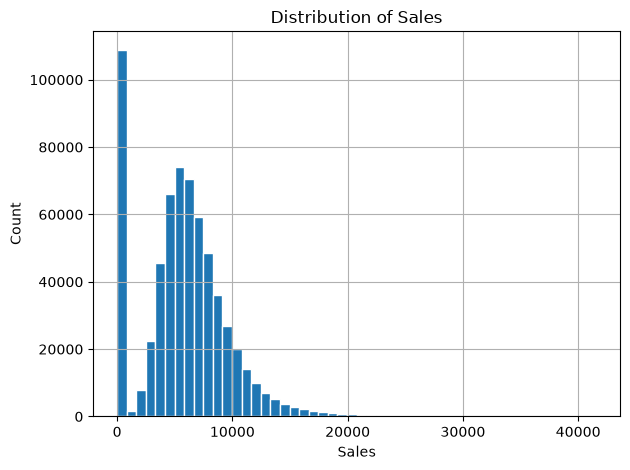

In [7]:
import matplotlib.pyplot as plt

df["sales"].hist(bins=50, edgecolor="white")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.title("Distribution of Sales")
plt.tight_layout()
plt.show()

In [8]:
df.sort_values("sales").head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
640812,49811,870,3,2014-07-23,0,0,0,0,1,0
573278,407993,261,7,2014-06-01,0,0,0,0,0,0
194399,668708,880,7,2014-03-16,0,0,0,0,0,0
546050,389639,472,2,2013-01-01,0,0,0,a,1,0
226300,79528,713,7,2014-08-03,0,0,0,0,0,0


In [9]:
df["sales"].value_counts()

sales
0        108855
5674        146
6049        134
5449        130
5723        128
          ...  
783           1
18891         1
27154         1
17964         1
16737         1
Name: count, Length: 20129, dtype: int64

### 3.3 Special checking why sales equl to zero

In [10]:
df[df["sales"] == 0]

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
6,600327,659,7,2014-06-08,0,0,0,0,0,0
10,561067,273,7,2014-10-05,0,0,0,0,0,0
18,409022,767,7,2013-01-27,0,0,0,0,0,0
34,605423,534,7,2014-06-08,0,0,0,0,0,0
35,231682,514,7,2014-03-09,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
640807,381567,167,7,2014-07-27,0,0,0,0,0,0
640812,49811,870,3,2014-07-23,0,0,0,0,1,0
640814,556209,650,7,2014-03-23,0,0,0,0,0,0
640834,304137,329,7,2013-09-15,0,0,0,0,0,0


if the shop is not open, sales = 0
if the shop is open, we predict the value

In [11]:
df[df["open"] == 0]["sales"].sum()

np.int64(0)

### 3.4 Bonus-Correlation

In [12]:
# corr_df = df[[]]
# corr_df.corr()

## 4 - Data Splitting

### date issue

In [34]:
date_df = df.copy()
date_df["date"] = pd.to_datetime(date_df["date"])
date_df["year"] = date_df["date"].dt.year
date_df["month"] = date_df["date"].dt.month

display(date_df.head())

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
0,425390,366,4,2013-04-18,517,1,0,0,0,4422,2013,4
1,291687,394,6,2015-04-11,694,1,0,0,0,8297,2015,4
2,411278,807,4,2013-08-29,970,1,1,0,0,9729,2013,8
3,664714,802,2,2013-05-28,473,1,1,0,0,6513,2013,5
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882,2013,10


In [14]:
date_sorted_df = date_df.sort_values(by=["year","month"])
date_sorted_df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
18,409022,767,7,2013-01-27,0,0,0,0,0,0,2013,1
43,129637,716,2,2013-01-15,383,1,0,0,0,4263,2013,1
68,325654,352,3,2013-01-30,517,1,0,0,0,5038,2013,1
80,324256,630,7,2013-01-06,0,0,0,0,0,0,2013,1
97,401790,1065,5,2013-01-18,480,1,0,0,0,3529,2013,1


In [38]:
# drop those not open rows
reduced_df = date_sorted_df[date_sorted_df["open"] != 0]

display(reduced_df.head(1))
display(reduced_df.sample(1))
display(reduced_df.tail(1))

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
43,129637,716,2,2013-01-15,383,1,0,0,0,4263,2013,1


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
529193,311583,1049,1,2013-06-24,589,1,0,0,0,3488,2013,6


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
640821,332752,691,6,2015-07-18,611,1,0,0,0,8316,2015,7


In [16]:
reduced_df.shape

(532016, 12)

In [17]:
X = reduced_df.drop(columns=[reduced_df.columns[0], 'sales', 'open'])

y = reduced_df['sales']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.7, shuffle=False)

X_val, X_test, y_val, y_test = train_test_split( X_temp, y_temp, test_size=0.5, shuffle=False)

print('X_train:', X_train.shape)
print('X_val: ', X_val.shape)
print('X_test: ', X_test.shape)

X_train: (159604, 9)
X_val:  (186206, 9)
X_test:  (186206, 9)


In [39]:
display(X_train.head(1))
display(X_train.tail(1))

,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,year,month
43,716,2,2013-01-15,383,0,0,0,2013,1


,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,year,month
635387,409,5,2013-09-13,625,1,0,0,2013,9


## 5 - Data Cleaning

In [19]:
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

### 5.1 - Remove the first column

In [20]:
for dataset in [X_train_clean, X_val_clean, X_test_clean]:
    dataset.drop(columns = [dataset.columns[0], "date"])

print("Drop the first and the date columns!")

Drop the first and the date columns!


In [21]:
X_train_clean.sample(5)

,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,year,month
328490,94,1,2013-01-07,918,1,0,0,2013,1
539452,901,2,2013-06-18,733,1,0,0,2013,6
399999,138,5,2013-06-28,706,0,0,0,2013,6
198618,165,1,2013-02-18,521,1,0,0,2013,2
535880,175,5,2013-08-30,812,1,0,0,2013,8


## 6 - Establish a Baseline Model

In [22]:
# DummyRegression()

from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# initialise the model
baseline_model = DummyRegressor(strategy="mean")

# train the dummy
baseline_model.fit(X_train_clean, y_train)

# prediction of the dummy
y_val_pred_dummy = baseline_model.predict(X_val_clean)

# evaluate the dummy
rmse = root_mean_squared_error(y_val, y_val_pred_dummy)
r2 = r2_score(y_val, y_val_pred_dummy)

print(f"Dummy's root-mean-squared error: {rmse}")
print(f"Dummy's R2-score: {r2}")

Dummy's root-mean-squared error: 3167.7622126926312
Dummy's R2-score: -0.010299901636208197


## 7 - Feature Engineering

### 7.1 - OneHotEncoder Catergory Feature

In [23]:
# check state-holiday:  One-Hot-Encoding
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import pickle

CAT_COL = 'state_holiday'
DROP_COLS = ['state_holiday', 'date', 'Unnamed: 0'] # text / date / row-id -> not features

# Fit on TRAIN only (no leakage). handle_unknown='ignore' -> same columns in every split.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoder.fit(X_train_clean[[CAT_COL]])



def encode(data):
    """One-hot encode state_holiday and drop non-feature columns.
    Always uses the SAME fitted encoder -> consistent columns across train/val/test/inference."""
    data = data.copy()
    arr = encoder.transform(data[[CAT_COL]])
    cols = encoder.get_feature_names_out([CAT_COL])
    enc= pd.DataFrame(arr, columns=cols, index=data.index)
    data = data.drop(columns=DROP_COLS, errors='ignore')
    return pd.concat([data, enc], axis=1)



# Apply to all splits
X_train_enc = encode(X_train_clean)
X_val_enc = encode(X_val_clean)
X_test_enc = encode(X_test_clean)

# Save the fitted encoder to share with the inference teammate
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Quick check: same columns everywhere, all numeric
print('train:', X_train_enc.shape, '| val:', X_val_enc.shape, '| test:', X_test_enc.shape)
print('same columns:', list(X_train_enc.columns) == list(X_val_enc.columns) == list(X_test_enc.columns))
X_train_enc.head()

train: (159604, 9) | val: (186206, 9) | test: (186206, 9)
same columns: True


d:\22_AI\23-aie\ironhack_ai\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\22_AI\23-aie\ironhack_ai\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
43,716,2,383,0,0,2013,1,0.0,0.0
68,352,3,517,0,0,2013,1,0.0,0.0
97,1065,5,480,0,0,2013,1,0.0,0.0
98,501,5,537,0,0,2013,1,0.0,0.0
115,390,6,956,0,0,2013,1,0.0,0.0


In [24]:
X_train_enc.columns

Index(['store_ID', 'day_of_week', 'nb_customers_on_day', 'promotion',
       'school_holiday', 'year', 'month', 'state_holiday_a',
       'state_holiday_b'],
      dtype='str')

### 7.2 - Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
# DONNOT NEED OPEN COLUMN!! CHANGE

continuous_features = ['store_ID', 'day_of_week', 'nb_customers_on_day', 'year', 'month']
binary_features = ['open', 'promotion', 'school_holiday','state_holiday_a', 'state_holiday_b']

scaler = StandardScaler()

X_train_fe = X_train_enc.copy()
X_val_fe = X_val_enc.copy()
X_test_fe = X_test_enc.copy()

X_train_fe[continuous_features] = scaler.fit_transform(X_train_enc[continuous_features])
X_val_fe[continuous_features] = scaler.transform(X_val_enc[continuous_features])
X_test_fe[continuous_features] = scaler.transform(X_test_enc[continuous_features])

In [26]:
X_train_fe.head()

,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
43,0.492133,-0.891704,-0.923752,0,0,0.0,-1.558,0.0,0.0
68,-0.640600,-0.311388,-0.584041,0,0,0.0,-1.558,0.0,0.0
97,1.578187,0.849243,-0.677842,0,0,0.0,-1.558,0.0,0.0
98,-0.176926,0.849243,-0.533338,0,0,0.0,-1.558,0.0,0.0
115,-0.522347,1.429558,0.528892,0,0,0.0,-1.558,0.0,0.0


## 8 - Feature Selection


### 8.1 - Check for multicollinearity

In [30]:
numeric_cols_for_corr = ['store_ID', 'day_of_week', 'nb_customers_on_day', 'promotion',
       'school_holiday', 'year', 'month', 'state_holiday_a',
       'state_holiday_b']

corr_fs = X_train_fe[numeric_cols_for_corr].corr()

display(corr_fs.round(2))

,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
store_ID,1.00,-0.00,0.04,-0.00,-0.00,NaN,0.00,0.01,0.00
day_of_week,-0.00,1.00,-0.10,-0.29,-0.13,NaN,-0.00,-0.00,-0.01
nb_customers_on_day,0.04,-0.10,1.00,0.19,0.02,NaN,0.01,0.02,0.04
promotion,-0.00,-0.29,0.19,1.00,0.01,NaN,-0.01,0.01,-0.00
school_holiday,-0.00,-0.13,0.02,0.01,1.00,NaN,0.19,-0.00,0.03
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.00,-0.00,0.01,-0.01,0.19,NaN,1.00,-0.00,-0.01
state_holiday_a,0.01,-0.00,0.02,0.01,-0.00,NaN,-0.00,1.00,-0.00
state_holiday_b,0.00,-0.01,0.04,-0.00,0.03,NaN,-0.01,-0.00,1.00


In [42]:
X_train_fe["year"].nunique()

1

In [45]:
X_train_fs = X_train_fe.copy()
X_val_fs = X_val_fe.copy()
X_test_fs = X_test_fe.copy()

print(f"X_train_fs Shape: {X_train_fs.shape}")
print(f"X_val_fs Shape: {X_val_fs.shape}")
print(f"X_test_fs Shape: {X_test_fs.shape}")

X_train_fs Shape: (159604, 9)
X_val_fs Shape: (186206, 9)
X_test_fs Shape: (186206, 9)


## 10 - Train and Compare Different Models

In [48]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


def evaluate_regressor(model, model_name, X_train, y_train, X_val, y_val):
    # Train the model on the train data
    _ = model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # 3. Calculate the metrices
    return {
        "model": model_name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "train_r2": r2_score(y_train, y_train_pred),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "val_r2": r2_score(y_val, y_val_pred),
        }

# 4. Collect all the performance results in a list
model_results = []

In [49]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_result = evaluate_regressor(
    lr_model,
    "Linear Regression",
    X_train.select_dtypes(include=[np.number]),
    y_train,
    X_val.select_dtypes(include=[np.number]),
    y_val,
    )

model_results.append(lr_result)

In [50]:
# 2. Linear regression with Ridge Regularization

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_result = evaluate_regressor(
    ridge_model,
    "Ridge Regression",
    X_train.select_dtypes(include=[np.number]),
    y_train,
    X_val.select_dtypes(include=[np.number]),
    y_val,
)

model_results.append(ridge_result)

In [51]:
# 3. Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

rf_result = evaluate_regressor(
    rf_model,
    "Random Forest",
    X_train.select_dtypes(include=[np.number]),
    y_train,
    X_val.select_dtypes(include=[np.number]),
    y_val,
)

model_results.append(rf_result)

In [ ]:
# 4. XGBoost
%pip install xgboost # ----> XGBoost doesn't come from Scikit learn. This ensures it gets installed
print("pip xgboost done")

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
)

xgb_result = evaluate_regressor(
    xgb_model,
    "XGBoost",
    X_train.select_dtypes(include=[np.number]),
    y_train,
    X_val.select_dtypes(include=[np.number]),
    y_val,
)

model_results.append(xgb_result)


[optparse.groups]Usage:[/]   
  d:\22_AI\23-aie\ironhack_ai\.venv\Scripts\python.exe -m pip install \[options] <requirement specifier> \[package-index-options] ...
  d:\22_AI\23-aie\ironhack_ai\.venv\Scripts\python.exe -m pip install \[options] -r <requirements file> \[package-index-options] ...
  d:\22_AI\23-aie\ironhack_ai\.venv\Scripts\python.exe -m pip install \[options] [-e] <vcs project url> ...
  d:\22_AI\23-aie\ironhack_ai\.venv\Scripts\python.exe -m pip install \[options] [-e] <local project path> ...
  d:\22_AI\23-aie\ironhack_ai\.venv\Scripts\python.exe -m pip install \[options] <archive url/path> ...

no such option: ----


Note: you may need to restart the kernel to use updated packages.
pip xgboost done


In [58]:
# print the list with all the model results

import pandas as pd

display(pd.DataFrame(model_results))

,model,train_rmse,train_r2,val_rmse,val_r2
0,Linear Regression,1509.378078,0.743508,1658.373417,0.723108
1,Ridge Regression,1509.378078,0.743508,1658.373529,0.723108
2,Random Forest,1216.853102,0.833293,1415.138381,0.798376
3,XGBoost,1344.315811,0.796539,1503.552709,0.772395
4,XGBoost,1344.315811,0.796539,1503.552709,0.772395


In [ ]:
'''
1. StandarScaler ? check if needed 
 feature selection

2. other model,(linearRegression almost done)

3. inference dataset, download dataset, clean/deal with it? prepar for the final evaluation
'''

## 11 - Hyperparameter Tuning

## 12 - Final Evaluation on Test Set 

In [64]:
display(X_train_fs.head(2))
display(X_val_fs.head(2))
display(X_test_fs.head(2))


,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
43,0.492133,-0.891704,-0.923752,0,0,0.0,-1.558,0.0,0.0
68,-0.640600,-0.311388,-0.584041,0,0,0.0,-1.558,0.0,0.0


,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
635391,0.582378,-0.891704,0.179041,1,0,0.0,1.525738,0.0,0.0
635455,1.463046,0.849243,-0.644885,0,0,0.0,1.525738,0.0,0.0


,store_ID,day_of_week,nb_customers_on_day,promotion,school_holiday,year,month,state_holiday_a,state_holiday_b
520850,1.363466,-1.472019,0.404669,1,1,1.0,1.140271,0.0,0.0
520864,0.495245,-0.311388,-0.622068,0,0,1.0,1.140271,0.0,0.0


In [61]:
final_model = rf_model
print("Done")

Done


### ???

## 13 - Exporting our model (Pickle)

In [67]:
import pickle

with open("final_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved.")

Model saved.
